# 01 - Exploratory Data Analysis

**Model objective:** classify task duration into duration buckets, such as Short, Standard, or Long-Running, using relevant raw Jira ticket fields.

### 01-01 Loading Raw Dataset


Load the raw Jira CSV and the plotting tools used throughout this notebook.

- **Pandas** handles tabular inspection and simple feature checks.
- **Matplotlib** provides lightweight plots for quick EDA.

The goal here is not to clean the dataset yet. This notebook identifies the main data-quality issues that the next notebook should handle.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

ticket_df = pd.read_csv('../jira_ticket_dataset.csv')

## 01-02 Dataset shape and memory inspection

Start by inspecting the dataset size, memory usage, column types, and a small sample of rows. These checks give a quick sense of whether the data is large, sparse, or mixed-type before selecting features.

In [2]:
print(f"Rows: {ticket_df.shape[0]:,}")
print(f"Columns: {ticket_df.shape[1]:,}")

display(ticket_df.dtypes.value_counts().rename("column_count"))
ticket_df.info(memory_usage="deep")

ticket_df.sample(5, random_state=42)

Rows: 1,149,323
Columns: 37


str        26
float64    10
object      1
Name: column_count, dtype: int64

<class 'pandas.DataFrame'>
RangeIndex: 1149323 entries, 0 to 1149322
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   id                           1131224 non-null  float64
 1   key                          1149323 non-null  str    
 2   summary                      1131223 non-null  str    
 3   resolution.id                946655 non-null   float64
 4   resolution.description       928770 non-null   str    
 5   resolution.name              946655 non-null   str    
 6   priority.id                  1117464 non-null  float64
 7   priority.name                1117464 non-null  str    
 8   labels                       1131004 non-null  str    
 9   assignee                     780217 non-null   str    
 10  status.id                    1131224 non-null  float64
 11  status.description           1123393 non-null  str    
 12  status.name                  1131224 non-null  str   

,id,key,summary,resolution.id,resolution.description,resolution.name,priority.id,priority.name,labels,assignee,...,project.key,project.name,projectCategory.id,projectCategory.description,projectCategory.name,resolutiondate,watches.watchCount,created,updated,description
362921,12523653.0,SMXCOMP-905,ensure DONE status is set when cxf bc consumer...,1.0,A fix for this issue is checked into the tree ...,Fixed,3.0,Major,[],83fabe05,...,SMXCOMP,ServiceMix Components,10480.0,ServiceMix Enterprise Service Bus,ServiceMix,2011-09-20 07:03:49,0.0,2011-09-20 06:26:44,2011-09-20 07:03:49,this can prevent potential thread leak
431071,12722862.0,UIMA-3908,Review UIMA-AS support for running with embedd...,3.0,The problem is a duplicate of an existing issue.,Duplicate,3.0,Major,[],baaaf95c,...,UIMA,UIMA,10410.0,Apache UIMA,UIMA,2014-06-27 19:21:37,1.0,2014-06-20 22:39:19,2014-06-27 19:21:37,UIMA-AS needs to support embedded AMQ broker. ...
580054,13095949.0,LIVY-311,Set classpath in MiniCluster only when it is n...,1.0,A fix for this issue is checked into the tree ...,Fixed,3.0,Major,[],46920e83,...,LIVY,Livy,NaN,NaN,NaN,2017-02-16 01:19:18,1.0,2017-02-08 06:23:57,2017-02-16 01:19:18,NaN
164680,12704840.0,SPARK-859,Remove the executor count from the header,1.0,A fix for this issue is checked into the tree ...,Fixed,3.0,Major,[],3b73e472,...,SPARK,Spark,NaN,NaN,NaN,2013-08-06 21:57:27,1.0,2013-08-05 15:12:06,2013-08-06 21:57:27,NaN
994340,13585790.0,HUDI-7988,ListingBasedRollbackStrategy support logcompact,1.0,A fix for this issue is checked into the tree ...,Fixed,3.0,Major,['pull-request-available'],99fd0329,...,HUDI,Apache Hudi,NaN,NaN,NaN,2024-07-17 09:42:27,1.0,2024-07-15 08:06:35,2024-07-17 09:42:27,[1. https://github.com/apache/hudi/issues/1158...


## 01-03 Selected feature availability

Based on the dataframe inspection, the most relevant raw features to keep for initial modeling are:

- **summary**: ticket title or short task description
- **description**: longer issue details
- **priority.name**: priority category
- **labels**: assigned Jira labels
- **issuetype.description**: description of the issue type
- **issuetype.name**: issue type label
- **issuetype.subtask**: whether the issue is a subtask
- **resolutiondate**: timestamp used to derive duration
- **created**: timestamp used to derive duration

Before narrowing the dataframe, check that each selected feature exists and how complete it is.

In [3]:
raw_feature_columns = [
    "summary",
    "description",
    "priority.name",
    "labels",
    "issuetype.description",
    "issuetype.name",
    "issuetype.subtask",
    "resolutiondate",
    "created",
]

feature_availability = pd.DataFrame({
    "feature": raw_feature_columns,
    "available": [column in ticket_df.columns for column in raw_feature_columns],
})
feature_availability["non_missing_count"] = [
    ticket_df[column].notna().sum() if column in ticket_df.columns else 0
    for column in raw_feature_columns
]
feature_availability["non_missing_percent"] = (
    feature_availability["non_missing_count"] / len(ticket_df) * 100
)

display(feature_availability)

ticket_df = ticket_df[raw_feature_columns].copy()
ticket_df.head()

,feature,available,non_missing_count,non_missing_percent
0,summary,True,1131223,98.425160
1,description,True,1026080,89.276905
2,priority.name,True,1117464,97.228020
3,labels,True,1131004,98.406105
4,issuetype.description,True,1130064,98.324318
5,issuetype.name,True,1131224,98.425247
6,issuetype.subtask,True,1131224,98.425247
7,resolutiondate,True,946715,82.371535
8,created,True,1131224,98.425247


,summary,description,priority.name,labels,issuetype.description,issuetype.name,issuetype.subtask,resolutiondate,created
0,Update config browser to work with the new syntax,The config browser used Velocity calling the t...,Minor,[],An improvement or enhancement to an existing f...,Improvement,False,2005-01-01 07:50:46,2005-01-01 07:47:50
1,XALAN_C 1.9 or current do not build on Fedora ...,Two types of errors:\n1- runConfigure and conf...,Blocker,[],A problem which impairs or prevents the functi...,Bug,False,2004-12-30 05:30:36,2004-12-25 22:50:30
2,"Problem with ADD new post, and DELETE post.","When trying to add new post, I was getting nex...",Critical,[],A problem which impairs or prevents the functi...,Bug,False,2005-01-02 15:21:00,2005-01-01 13:52:46
3,LogHandler can only work in GlobalConfiguratio...,org.apache.axis.handlers.LogHandler in request...,Major,[],A problem which impairs or prevents the functi...,Bug,False,NaN,2005-01-02 19:13:37
4,Decoding of service is broken in org.apache.ax...,The following code assumes a lot of things:\n\...,Major,[],A problem which impairs or prevents the functi...,Bug,False,NaN,2005-01-03 03:34:52


## 01-04 Missing values

Missing values are one of the first issues to inspect because they determine what can safely move into the cleaning notebook.

For this project, **created**, **resolutiondate**, and **summary** are non-negotiable fields:

- missing **created** or **resolutiondate** means `duration_days` cannot be calculated.
- missing **summary** removes a key text signal for model training.

The next plots show where missingness is concentrated and how much of the selected dataset is affected.

,missing_count,missing_percent
resolutiondate,202608,17.628465
description,123243,10.723095
priority.name,31859,2.771980
issuetype.description,19259,1.675682
labels,18319,1.593895
summary,18100,1.574840
issuetype.name,18099,1.574753
issuetype.subtask,18099,1.574753
created,18099,1.574753


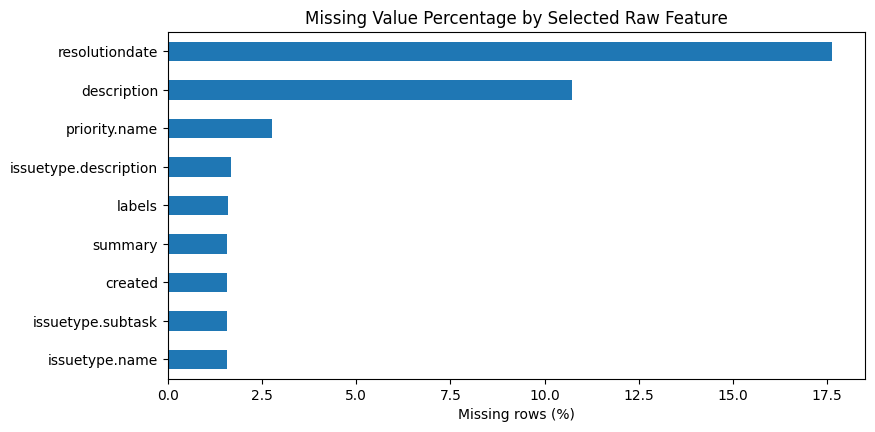

In [4]:
missing_table = pd.DataFrame({
    "missing_count": ticket_df.isna().sum(),
    "missing_percent": ticket_df.isna().mean() * 100
}).sort_values("missing_percent", ascending=False)

display(missing_table)


fig, ax = plt.subplots(figsize=(9, 4.5))
missing_table["missing_percent"].sort_values().plot(
    kind="barh",
    ax=ax,
    title="Missing Value Percentage by Selected Raw Feature"
)

ax.set_xlabel("Missing rows (%)")
ax.set_ylabel("")

plt.show()

**Rows with missing resolutiondate cannot be used for the first duration classification model because the target duration cannot be calculated.**

This chart highlights which selected raw features have the highest missing-value rates. A high missing percentage does not always mean a column is useless, but it does mean the cleaning notebook must handle that field deliberately.


#### Check most frequent values and their percentages

It can help to see if theree exists an overarching variable that skews any raw feature.

In [5]:
# normalize=True finds the column varaiable count percentage between 0 - 1 then we use max to find the most frequent and find the percentage 

most_freq = pd.DataFrame({
    "most_freq_variable": ticket_df.value_counts().idxmax(),
    "most_freq_percentage": ticket_df.apply(lambda x: x.value_counts(normalize=True).max() * 100)
})

display(most_freq)

,most_freq_variable,most_freq_percentage
summary,HDFS Web UI displays comments from dfs.exclude...,0.015293
description,I am putting comments in dfs.exclude file such...,0.011500
priority.name,Major,66.784165
labels,[],82.050727
issuetype.description,An improvement or enhancement to an existing f...,50.162823
issuetype.name,Improvement,50.111384
issuetype.subtask,False,90.894642
resolutiondate,2009-09-16 00:26:50,0.091791
created,2008-07-14 22:44:58,0.002298


It can be concluded that multiple of the chosen features can be further removed due to not being useful.

Such features we might have to take into consideration in removing or modifying are as follows:

- **labels**
- **issuetype.description**
- **issuetype.subtask** 

For simplicity it is better to remove these features, keeping our current raw features to:

- **summary**: ticket title or short task description
- **description**: longer issue details
- **priority.name**: priority category
- **issuetype.name**: issue type label
- **resolutiondate**: timestamp used to derive duration
- **created**: timestamp used to derive duration

In [6]:
ticket_df = ticket_df.drop(columns=["labels", "issuetype.description", "issuetype.subtask"])

Let's take a final look at our current raw features.

In [7]:
ticket_df.sample(n=3, random_state=42)

,summary,description,priority.name,issuetype.name,resolutiondate,created
362921,ensure DONE status is set when cxf bc consumer...,this can prevent potential thread leak,Major,Bug,2011-09-20 07:03:49,2011-09-20 06:26:44
431071,Review UIMA-AS support for running with embedd...,UIMA-AS needs to support embedded AMQ broker. ...,Major,Bug,2014-06-27 19:21:37,2014-06-20 22:39:19
580054,Set classpath in MiniCluster only when it is n...,NaN,Major,Improvement,2017-02-16 01:19:18,2017-02-08 06:23:57


## 01-05 Timestamp quality checks

The timestamp are checked by the following:

- Can **created** and **resolutiondate** be converted to datetime values?
- Are there extreme minimum or maximum dates that should be reviewed?
- Are there rows where **resolutiondate** happens before **created**?

In [9]:
# Convert dates to datetime for EDA checks.
ticket_df["created"] = pd.to_datetime(
    ticket_df["created"],
    errors="coerce",
    utc=True,
)

ticket_df["resolutiondate"] = pd.to_datetime(
    ticket_df["resolutiondate"],
    errors="coerce",
    utc=True,
)

timestamp_quality = pd.DataFrame({
    "missing_or_invalid_count": ticket_df[["created", "resolutiondate"]].isna().sum(),
    "earliest_value": ticket_df[["created", "resolutiondate"]].min(),
    "latest_value": ticket_df[["created", "resolutiondate"]].max(),
})

display(timestamp_quality)

invalid_duration_count = (ticket_df["resolutiondate"] < ticket_df["created"]).sum()
print(f"Rows where resolutiondate is before created: {invalid_duration_count:,}")

,missing_or_invalid_count,earliest_value,latest_value
created,18388,2000-10-19 09:27:07+00:00,2024-11-06 15:59:21+00:00
resolutiondate,202608,2002-05-10 18:54:17+00:00,2025-03-04 04:00:30+00:00


Rows where resolutiondate is before created: 18


## 01-06 Duration target exploration

The main target feature is `duration_days`, calculated as:

`duration_days = resolutiondate - created`

This section inspects the raw numeric target before creating classes. The goal is to understand spread, missing values, negative values, and extreme values at a basic level.

In [10]:
eda_df = ticket_df.copy()
eda_df["duration_days"] = (eda_df["resolutiondate"] - eda_df["created"]).dt.total_seconds() / 86400

duration_summary = eda_df["duration_days"].describe()
display(duration_summary)

negative_duration_count = (eda_df["duration_days"] < 0).sum()
missing_duration_count = eda_df["duration_days"].isna().sum()
print(f"Missing duration rows: {missing_duration_count:,}")
print(f"Negative duration rows: {negative_duration_count:,}")

count    946426.000000
mean        203.954379
std         520.375742
min          -0.372951
25%           1.049771
50%          11.915307
75%         112.017925
max        8001.517257
Name: duration_days, dtype: float64

Missing duration rows: 202,897
Negative duration rows: 18


In [11]:
eda_df["duration_days"].quantile([
    0.00,
    0.01,
    0.05,
    0.10,
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99,
    1.00,
])

0.00      -0.372951
0.01       0.000868
0.05       0.009699
0.10       0.059016
0.25       1.049771
0.50      11.915307
0.75     112.017925
0.90     623.853941
0.95    1199.511267
0.99    2694.205712
1.00    8001.517257
Name: duration_days, dtype: float64

## 01-07 Duration class distribution

Create simple duration classes from `duration_days` and compare how many records fall into each group. These classes are exploratory and can be adjusted during cleaning or modeling.

duration_range
Quick         319407
Standard       94631
Extended      121216
Long-range    403264
Name: task_count, dtype: int64

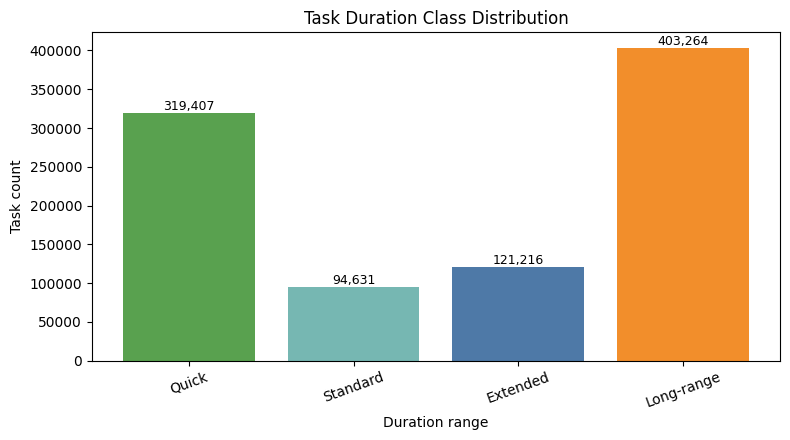

In [ ]:
# Basic cleaning only for visualization in this EDA notebook.
# The formal cleaning steps are handled in 02-data-cleaning.ipynb.

cleaned_df = ticket_df.drop_duplicates()
cleaned_df = cleaned_df.dropna(subset=["created", "resolutiondate", "summary"]).copy()

# convert dates to datetime dtype

cleaned_df["created"] = pd.to_datetime(cleaned_df["created"], errors="coerce", utc=True)
cleaned_df["resolutiondate"] = pd.to_datetime(cleaned_df["resolutiondate"], errors="coerce", utc=True)

# duration_days = resolutiondate - created

cleaned_df["duration_days"] = (cleaned_df["resolutiondate"] - cleaned_df["created"]).dt.total_seconds() / (60 * 60 * 24)
cleaned_df = cleaned_df[cleaned_df["duration_days"].notna() & (cleaned_df["duration_days"] >= 0)]

def duration_range(days):
    if days <= 3:
        return "Quick"
    if days <= 7:
        return "Standard"
    if days <= 21:
        return "Extended"
    return "Long-range"

duration_order = ["Quick", "Standard", "Extended", "Long-range"]
cleaned_df["duration_range"] = cleaned_df["duration_days"].apply(duration_range)
duration_counts = cleaned_df["duration_range"].value_counts().reindex(duration_order)

display(duration_counts.rename("task_count"))

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(duration_counts.index, duration_counts.values, color=["#59A14F", "#76B7B2", "#4E79A7", "#F28E2B", "#E15759"])
ax.set_title("Task Duration Class Distribution")
ax.set_xlabel("Duration range")
ax.set_ylabel("Task count")
ax.tick_params(axis="x", rotation=20)

# UI logic for text above bars

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

The class distribution shows whether the target is balanced or dominated by short or long tasks.

The next two simple plots inspect the shortest and longest duration ranges more closely because those ranges are likely to drive cleaning decisions.

##### 'Quick' label duration check

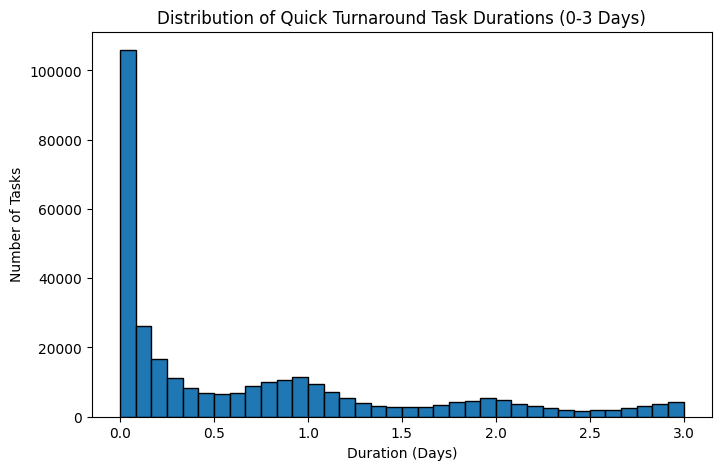

In [13]:
quick_df = cleaned_df[(cleaned_df["duration_days"] >= 0) & (cleaned_df["duration_days"] <= 3)]

# each rectangle represents 2 hrs

plt.figure(figsize=(8, 5))
plt.hist(quick_df["duration_days"], bins=36, edgecolor="black")
plt.title("Distribution of Quick Turnaround Task Durations (0-3 Days)")
plt.xlabel("Duration (Days)")
plt.ylabel("Number of Tasks")
plt.show()

The shortest tasks appear concentrated near the beginning of the range. The cleaning notebook should decide whether very short tasks are valid work items or need a separate class.

##### 'Long-range' label duration check

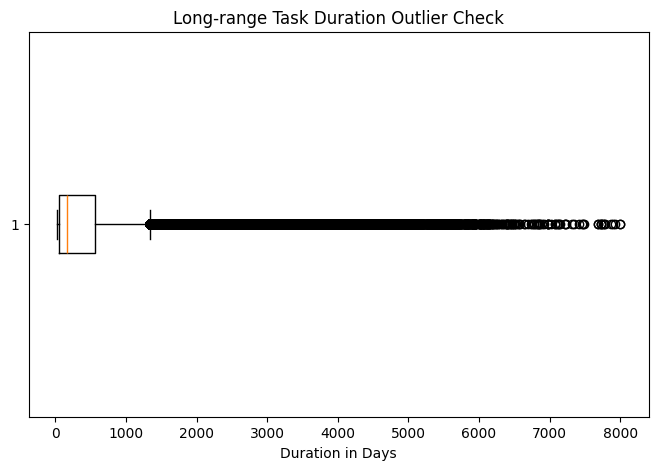

In [14]:
long_range_duration = cleaned_df.loc[
    cleaned_df["duration_days"] > 21,
    "duration_days",
].dropna()

plt.figure(figsize=(8, 5))
plt.boxplot(long_range_duration, vert=False)
plt.title("Long-range Task Duration Outlier Check")
plt.xlabel("Duration in Days")
plt.show()

The long-range boxplot shows that some tickets remain open much longer than the typical long-range task. These values should be reviewed in cleaning before model training.

##### Class percentages

In [15]:
class_percentages = (cleaned_df["duration_range"].value_counts(normalize=True).reindex(duration_order).mul(100).round(2))
class_percentages

duration_range
Quick         34.03
Standard      10.08
Extended      12.92
Long-range    42.97
Name: proportion, dtype: float64

## 01-08 Text feature exploration

Text fields are useful because task summaries and descriptions often contain signals about complexity. This section keeps the checks basic by looking at missing values, blank strings, and character lengths.

,feature,missing_count,blank_count,average_characters,median_characters,max_characters
0,summary,0,0,57.122085,54.0,255
1,description,92479,92576,1049.391875,325.0,8577458


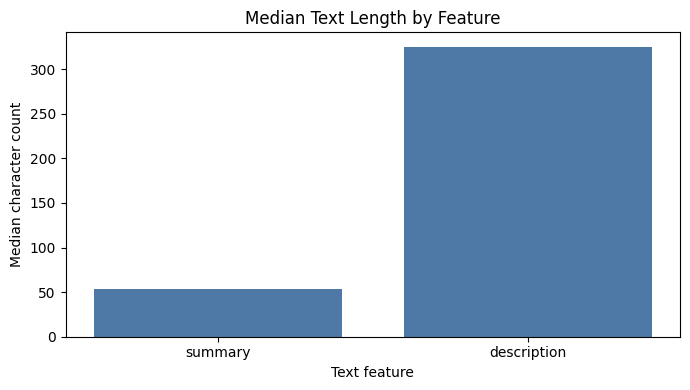

In [16]:
text_columns = ["summary", "description"]
text_summary = []

for column in text_columns:
    # extract non-empty feature attributes

    text_values = cleaned_df[column].astype("string")
    text_lengths = text_values.fillna("").str.len()
    blank_count = text_values.fillna("").str.strip().eq("").sum()

    text_summary.append({
        "feature": column,
        "missing_count": text_values.isna().sum(),
        "blank_count": blank_count,
        "average_characters": text_lengths.mean(),
        "median_characters": text_lengths.median(),
        "max_characters": text_lengths.max(),
    })

text_summary_df = pd.DataFrame(text_summary)
display(text_summary_df)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(text_summary_df["feature"], text_summary_df["median_characters"], color="#4E79A7")
ax.set_title("Median Text Length by Feature")
ax.set_xlabel("Text feature")
ax.set_ylabel("Median character count")
plt.tight_layout()
plt.show()

## 01-09 Categorical feature exploration

Categorical fields help describe the type and priority of each task. The checks below look at unique value counts and the most frequent values so cleaning can decide whether rare categories should be grouped.

In [17]:
categorical_columns = ["priority.name", "issuetype.name"]

missing_count = []
unique_count = []

for cat in categorical_columns:
    missing_count.append(cleaned_df[cat].isna().sum())
    unique_count.append(cleaned_df[cat].nunique(dropna=True))

categorical_summary = pd.DataFrame({
    "feature": categorical_columns,
    "missing_count": missing_count,
    "unique_count": unique_count,
})

display(categorical_summary)

for column in categorical_columns:
    print(f"Top values for {column}")
    display(cleaned_df[column].value_counts(dropna=False).head(10))

,feature,missing_count,unique_count
0,priority.name,11846,15
1,issuetype.name,0,37


Top values for priority.name


priority.name
Major       614994
Minor       177625
Critical     43868
Blocker      34508
Trivial      26931
NaN          11846
Normal       11188
P2            6388
Low           6160
P3            2629
Name: count, dtype: int64

Top values for issuetype.name


issuetype.name
Bug                   479382
Improvement           224438
Sub-task               87658
Task                   63720
New Feature            51239
Test                   10239
Dependency upgrade      7167
Wish                    5221
Documentation           2011
Question                2005
Name: count, dtype: int64

## 01-10 EDA findings and cleaning decisions

Main findings from this EDA notebook:

- Keep the selected raw fields because they connect directly to the target or to simple model features.
- Drop rows that cannot produce the target, especially rows missing **created** or **resolutiondate**.
- Drop or review rows with invalid durations where **resolutiondate** is before **created**.
- Review very short durations separately because they may create a large short-task cluster.
- Review very long durations separately because they may represent stale or unusual tickets.
- Keep basic text-length features from **summary** and **description** after handling missing or blank text.
- Keep categorical fields such as priority and issue type, while grouping rare categories if needed later.
- Convert **labels** into simple count or top-label features after normalizing empty label values.

Cleaning notebook decisions to carry forward:

- Remove duplicate rows.
- Convert timestamp columns with errors="coerce" and handle invalid dates.
- Create duration_days only after timestamp checks.
- Remove negative or missing target durations before model training.
- Revisit the duration class cutoffs after checking class balance.